### Dataset Link

https://www.kaggle.com/datasets/alex1994/natural-disaster-image-dataset

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import torch
import warnings
import warnings
warnings.filterwarnings('ignore')
import os
import torch
import os

import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
from tqdm import tqdm
import timm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
# Dataset path
data_dir = "Dataset"

In [5]:
# Data transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

In [6]:
import splitfolders # or import splitfolders
output_dir = "output" #where you want the split datasets saved. one will be created if it does not exist or none is set
os.makedirs(output_dir, exist_ok=True)

splitfolders.ratio(data_dir, output=output_dir, seed=42, ratio=(.8, .2)) 

Copying files: 4428 files [00:35, 124.52 files/s]


In [7]:
# Load data
train_data = datasets.ImageFolder(os.path.join(output_dir, 'train'), transform=transform)
val_data = datasets.ImageFolder(os.path.join(output_dir, 'val'), transform=transform)

In [8]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

In [9]:
class_names = train_data.classes
print("Classes:", class_names)

Classes: ['cyclone', 'earthquake', 'flood', 'wildfire']


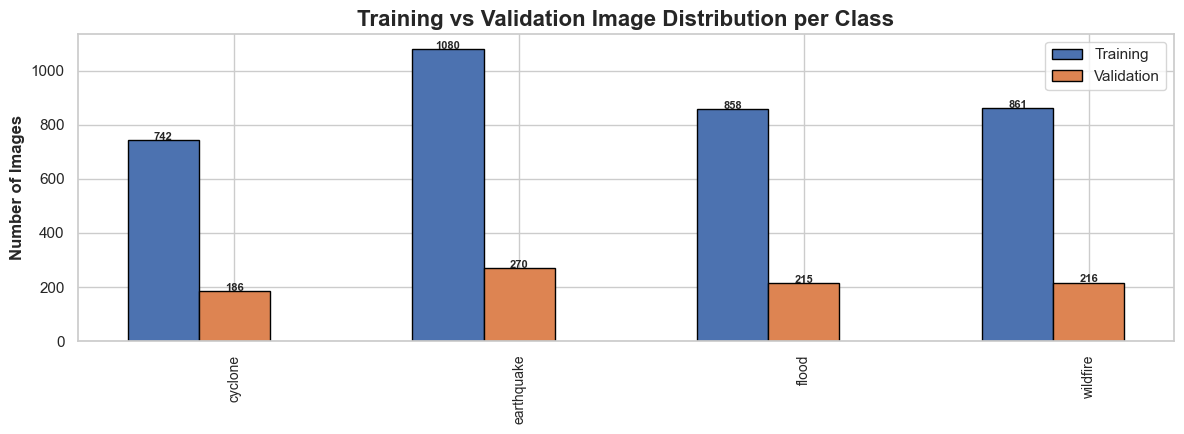

In [10]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Directories
train_dir = "output/train"
val_dir   = "output/val"

# COUNT IMAGES IN FOLDERS
def count_images(directory, classes):
    counts = []
    for label in classes:
        folder = os.path.join(directory, label)
        
        if not os.path.exists(folder):
            print(f"Warning: Folder not found -> {folder}")
            counts.append(0)
            continue
        
        count = len([
            f for f in os.listdir(folder)
            if os.path.isfile(os.path.join(folder, f))
        ])
        counts.append(count)
    return counts

# Get counts
train_counts = count_images(train_dir, class_names)
val_counts   = count_images(val_dir, class_names)

# PLOT
plt.figure(figsize=(12, 4.5))
sns.set(style="whitegrid")

x = range(len(class_names))
width = 0.25  # three bars → smaller width

plt.bar([i - width for i in x], train_counts, width=width,
        label="Training", edgecolor="black")

plt.bar(x, val_counts, width=width,
        label="Validation", edgecolor="black")


# Display values above each bar
for i in x:
    plt.text(i - width, train_counts[i] + 1, str(train_counts[i]),
             ha='center', fontsize=8, weight='bold')
    plt.text(i, val_counts[i] + 1, str(val_counts[i]),
             ha='center', fontsize=8, weight='bold')

plt.title("Training vs Validation Image Distribution per Class",
          fontsize=16, weight='bold')
plt.xticks(x, class_names, rotation=90, fontsize=10)
plt.ylabel("Number of Images", fontsize=12, weight='bold')
plt.legend()

plt.tight_layout()
plt.show()


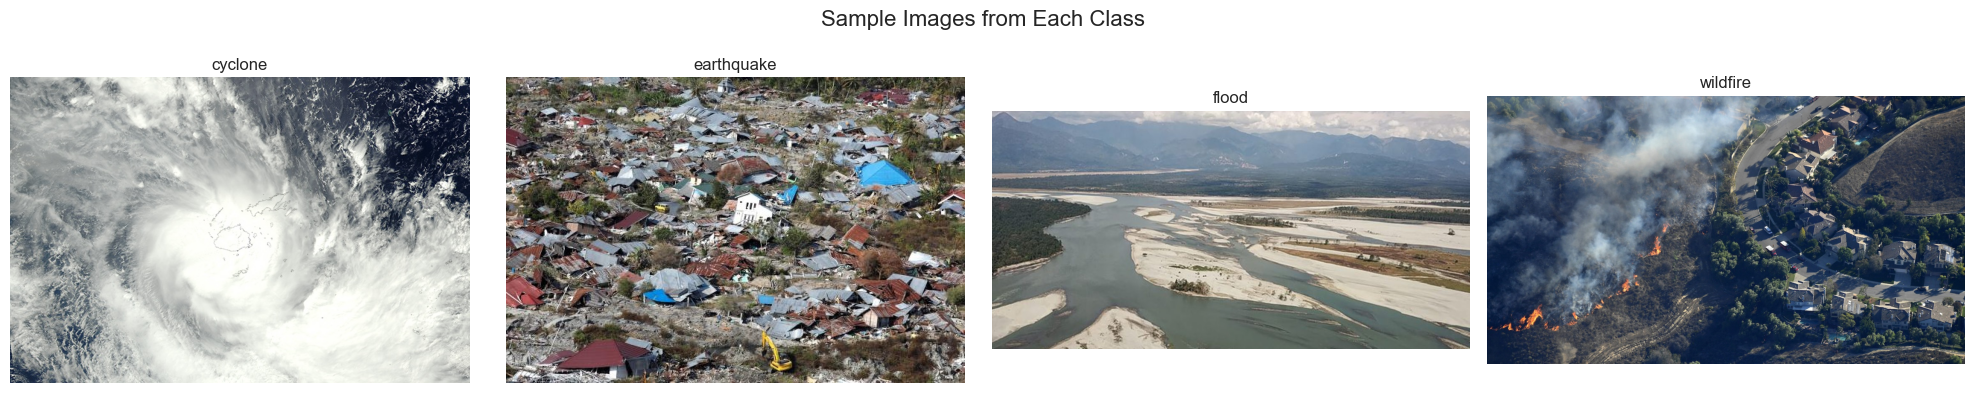

In [11]:
import matplotlib.image as mpimg
import math

num_class_names = len(class_names)
cols = 4  
rows = math.ceil(num_class_names / cols)

# Plot setup
plt.figure(figsize=(5 * cols, 4 * rows))

for idx, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    image_files = [f for f in os.listdir(class_path)
                   if os.path.isfile(os.path.join(class_path, f)) and f.lower().endswith(('.png', '.jpg', '.jpeg','.bmp'))]

    if image_files:
        img_path = os.path.join(class_path, image_files[0]) 
        img = mpimg.imread(img_path)

        plt.subplot(rows, cols, idx + 1)
        plt.imshow(img, cmap='gray')
        plt.title(class_name)
        plt.axis('off')

plt.suptitle('Sample Images from Each Class', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#  Model Training & Evaluation Loop

In [12]:
ML_Model, accuracy, precision, recall, f1score = [], [], [], [], []

def storeResults(model, a, b, c, d):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    recall.append(round(c, 3))
    f1score.append(round(d, 3))

In [13]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, device, model_name):
    model.to(device)
    history = {"accuracy": [], "val_accuracy": [], "loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0.0, 0, 0

        loop = tqdm(train_loader, desc=f"{model_name} Epoch {epoch+1}/{epochs}", leave=False)
        for batch in loop:
            inputs, labels = batch[0].to(device), batch[1].to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            loop.set_postfix(loss=loss.item(), acc=correct / total)

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for batch in val_loader:
                inputs, labels = batch[0].to(device), batch[1].to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        train_acc = correct / total
        val_acc = val_correct / val_total

        history["accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)
        history["loss"].append(train_loss / len(train_loader))
        history["val_loss"].append(val_loss / len(val_loader))

        print(f"{model_name} Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {val_acc:.4f}")

    return history



In [14]:
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

def evaluate_model(model, val_loader, device, labels, history, model_name):
    model.eval()
    model.to(device)

    y_true_, y_pred_, y_probs = [], [], []

    with torch.no_grad():
        for batch in val_loader:
            inputs, targets = batch[0].to(device), batch[1].to(device)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            y_true_.extend(targets.cpu().numpy())
            y_pred_.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    y_true_ = np.array(y_true_)
    y_pred_ = np.array(y_pred_)
    y_probs = np.array(y_probs)

    acc = accuracy_score(y_true_, y_pred_)
    prec = precision_score(y_true_, y_pred_, average="macro", zero_division=0)
    rec = recall_score(y_true_, y_pred_, average="macro", zero_division=0)
    f1 = f1_score(y_true_, y_pred_, average="macro", zero_division=0)

    print("\nClassification Report -", model_name)
    print(classification_report(y_true_, y_pred_, target_names=labels, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_true_, y_pred_)
    plt.figure(figsize=(15,10))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # Accuracy curves
    plt.figure(figsize=(5,4))
    plt.plot(history["accuracy"], label="Train Acc")
    plt.plot(history["val_accuracy"], label="Val Acc")
    plt.legend(); plt.title(f"Accuracy - {model_name}")
    plt.show()

    # Loss curves
    plt.figure(figsize=(5,4))
    plt.plot(history["loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.legend(); plt.title(f"Loss - {model_name}")
    plt.show()

    return acc, prec, rec, f1

In [15]:
num_classes = len(class_names)

# RESNET

In [16]:
resnet_model = timm.create_model(
    'resnet50',
    pretrained=True,
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet_model.parameters(), lr=0.001)


In [17]:
history_resnet = train_model(
    resnet_model, train_loader, val_loader,
    criterion, optimizer,
    epochs=5, device=device, model_name="ResNet50"
)


ResNet50 Epoch 1/5 | Train Loss: 0.3306 | Train Acc: 0.8890 | Val Loss: 0.1609 | Val Acc: 0.9481


ResNet50 Epoch 2/5 | Train Loss: 0.1168 | Train Acc: 0.9582 | Val Loss: 0.1133 | Val Acc: 0.9639


ResNet50 Epoch 3/5 | Train Loss: 0.0603 | Train Acc: 0.9794 | Val Loss: 0.1227 | Val Acc: 0.9628


ResNet50 Epoch 4/5 | Train Loss: 0.0714 | Train Acc: 0.9735 | Val Loss: 0.1633 | Val Acc: 0.9526


ResNet50 Epoch 5/5 | Train Loss: 0.0571 | Train Acc: 0.9811 | Val Loss: 0.1170 | Val Acc: 0.9628


In [18]:
torch.save(resnet_model.state_dict(), "Models/resnet50.pth")


Classification Report - ResNet50
              precision    recall  f1-score   support

     cyclone       0.98      0.96      0.97       186
  earthquake       0.96      0.96      0.96       270
       flood       0.94      0.94      0.94       215
    wildfire       0.96      0.99      0.97       216

    accuracy                           0.96       887
   macro avg       0.96      0.96      0.96       887
weighted avg       0.96      0.96      0.96       887



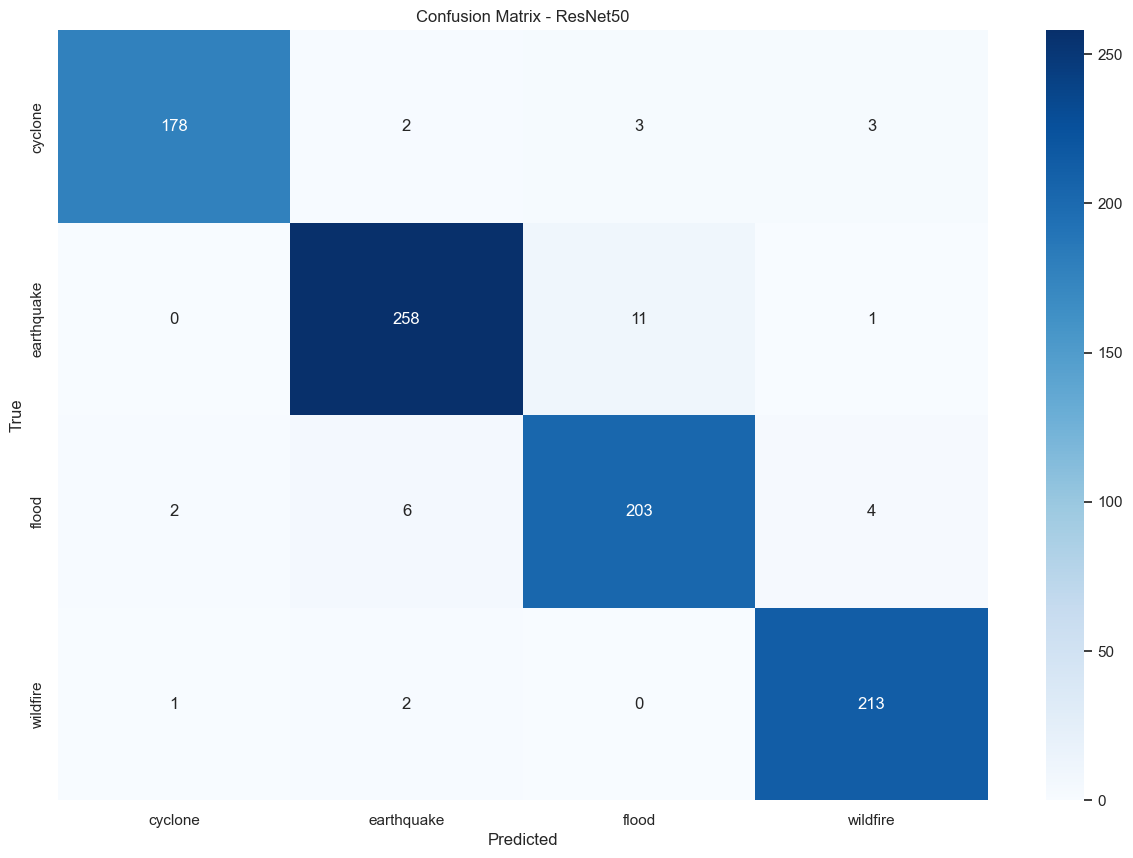

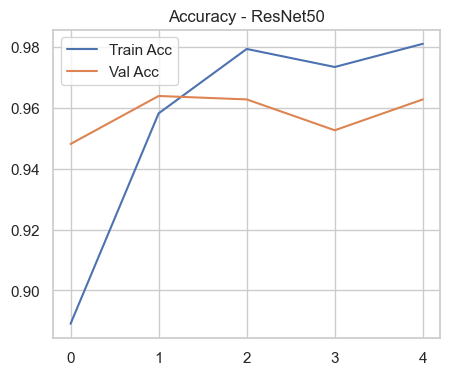

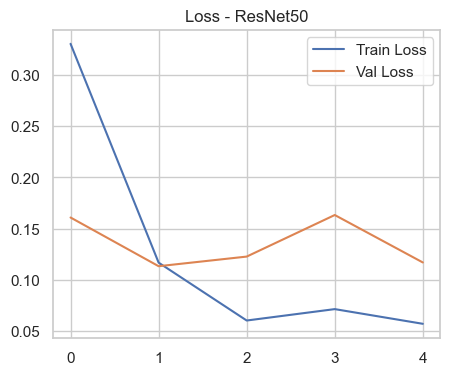

In [19]:
acc_r, prec_r, rec_r, f1_r = evaluate_model(
    resnet_model, val_loader, device, class_names, history_resnet, "ResNet50"
)


In [20]:
storeResults("ResNet50", acc_r, prec_r, rec_r, f1_r)

# VGG16

In [21]:
vgg16_model = timm.create_model(
    'vgg16_bn',         
    pretrained=True,
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(vgg16_model.parameters(), lr=0.001)

In [22]:
history_vgg16 = train_model(
    vgg16_model, train_loader, val_loader,
    criterion, optimizer,
    epochs=5, device=device, model_name="VGG16"
)

VGG16 Epoch 1/5 | Train Loss: 1.0583 | Train Acc: 0.5874 | Val Loss: 1.5985 | Val Acc: 0.5569


VGG16 Epoch 2/5 | Train Loss: 0.5518 | Train Acc: 0.8173 | Val Loss: 0.5120 | Val Acc: 0.8433


VGG16 Epoch 3/5 | Train Loss: 0.4091 | Train Acc: 0.8656 | Val Loss: 0.3241 | Val Acc: 0.8918


VGG16 Epoch 4/5 | Train Loss: 0.3159 | Train Acc: 0.8879 | Val Loss: 0.4409 | Val Acc: 0.8602


VGG16 Epoch 5/5 | Train Loss: 0.2815 | Train Acc: 0.8997 | Val Loss: 0.3974 | Val Acc: 0.8805


In [23]:
torch.save(vgg16_model.state_dict(), "Models/vgg16.pth")


Classification Report - VGG16
              precision    recall  f1-score   support

     cyclone       0.85      0.92      0.89       186
  earthquake       0.89      0.88      0.88       270
       flood       0.96      0.77      0.85       215
    wildfire       0.84      0.96      0.89       216

    accuracy                           0.88       887
   macro avg       0.89      0.88      0.88       887
weighted avg       0.89      0.88      0.88       887



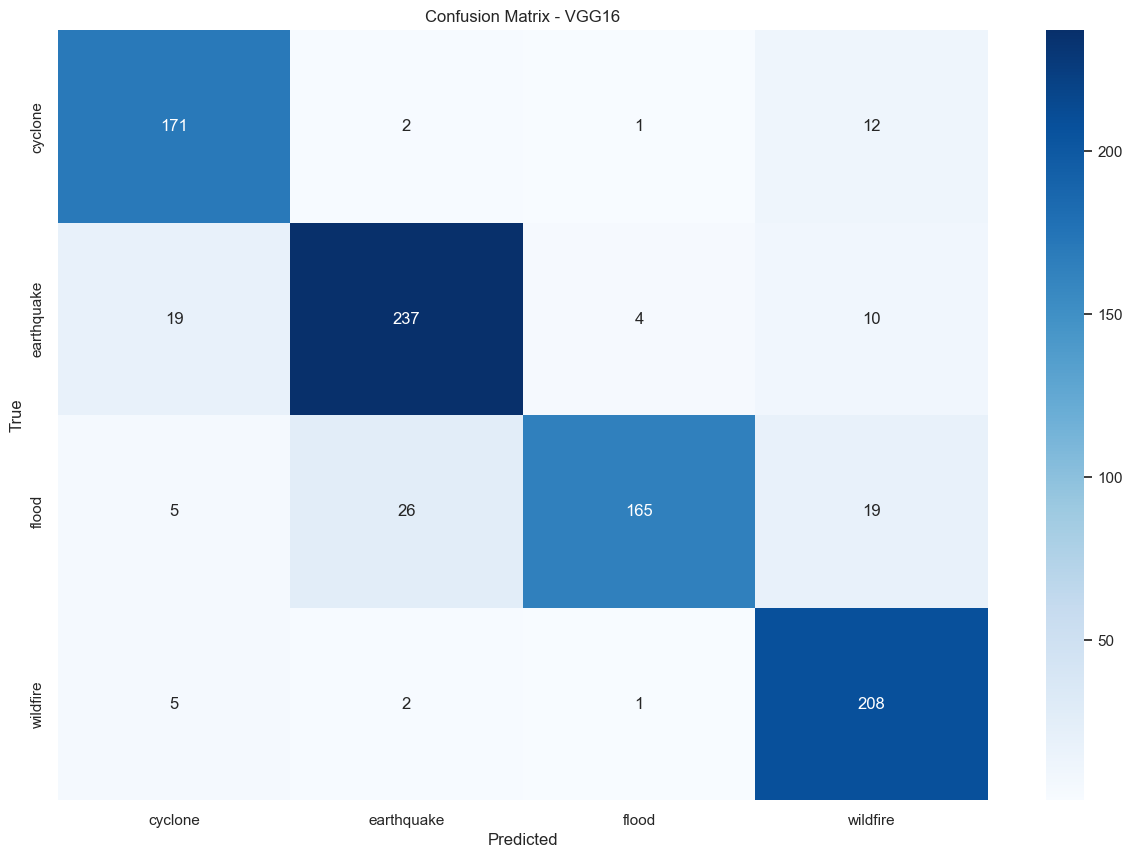

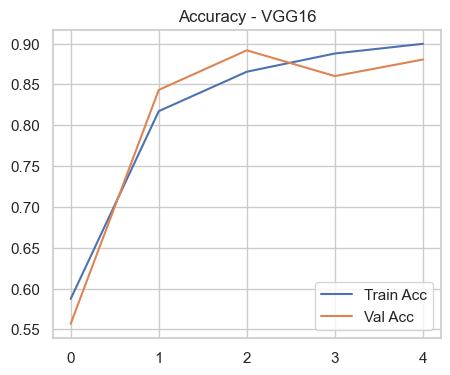

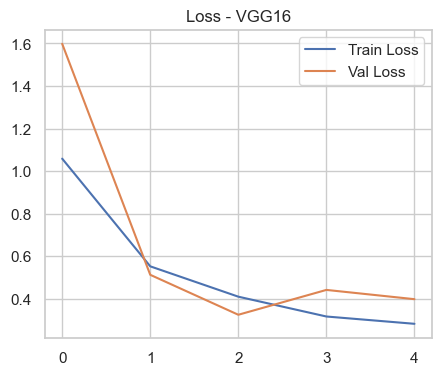

In [24]:
acc_v, prec_v, rec_v, f1_v = evaluate_model(
    vgg16_model, val_loader, device, class_names, history_vgg16, "VGG16"
)

In [25]:
storeResults("VGG16", acc_v, prec_v, rec_v, f1_v)

# MobileNetV2

In [26]:
mobilenet_model = timm.create_model(
    'mobilenetv2_100',
    pretrained=True,
    num_classes=num_classes
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mobilenet_model.parameters(), lr=0.001)

In [27]:
history_mobilenet = train_model(
    mobilenet_model, train_loader, val_loader,
    criterion, optimizer,
    epochs=5, device=device, model_name="MobileNet"
)


MobileNet Epoch 1/5 | Train Loss: 0.4660 | Train Acc: 0.8887 | Val Loss: 0.2278 | Val Acc: 0.9346


MobileNet Epoch 2/5 | Train Loss: 0.1046 | Train Acc: 0.9633 | Val Loss: 0.1320 | Val Acc: 0.9662


MobileNet Epoch 3/5 | Train Loss: 0.0723 | Train Acc: 0.9754 | Val Loss: 0.2269 | Val Acc: 0.9538


MobileNet Epoch 4/5 | Train Loss: 0.1248 | Train Acc: 0.9633 | Val Loss: 0.2288 | Val Acc: 0.9414


MobileNet Epoch 5/5 | Train Loss: 0.1124 | Train Acc: 0.9650 | Val Loss: 0.1552 | Val Acc: 0.9628


In [28]:
torch.save(mobilenet_model.state_dict(), "Models/mobilenet.pth")


Classification Report - MobileNet
              precision    recall  f1-score   support

     cyclone       0.99      0.97      0.98       186
  earthquake       0.95      0.96      0.95       270
       flood       0.93      0.95      0.94       215
    wildfire       0.98      0.97      0.97       216

    accuracy                           0.96       887
   macro avg       0.96      0.96      0.96       887
weighted avg       0.96      0.96      0.96       887



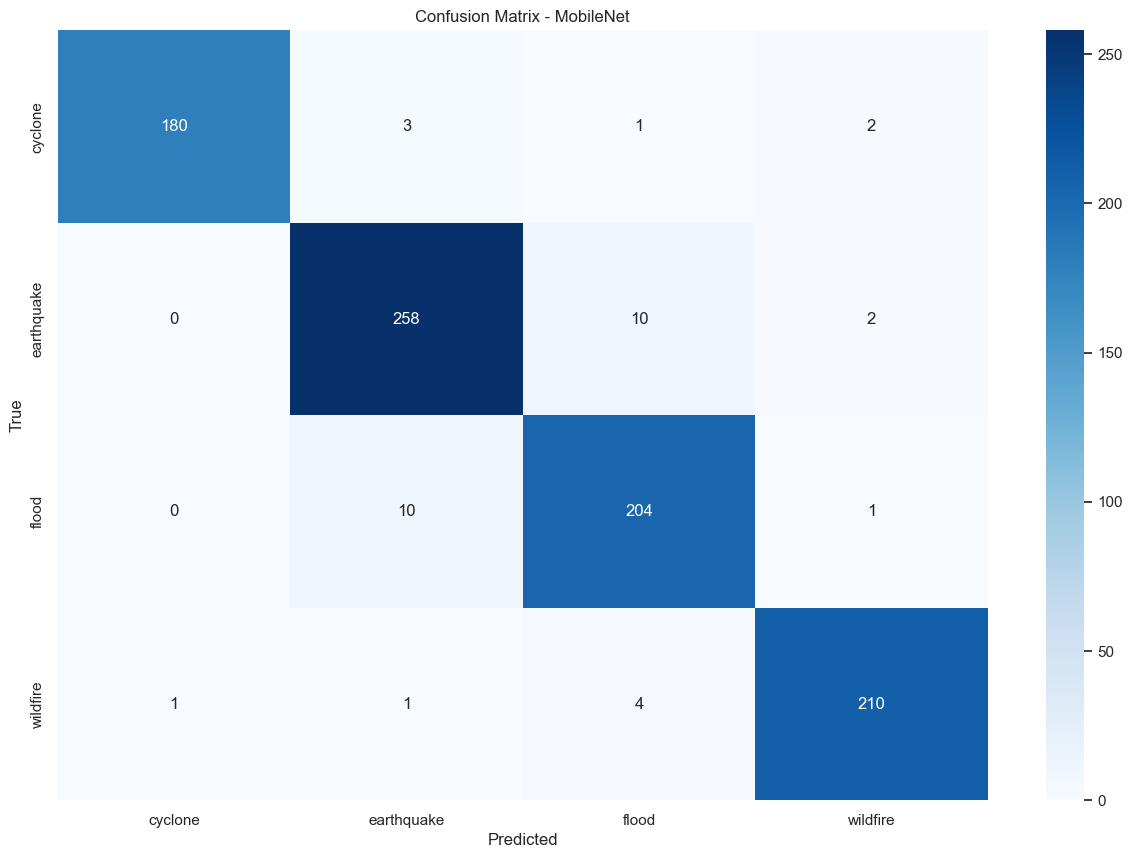

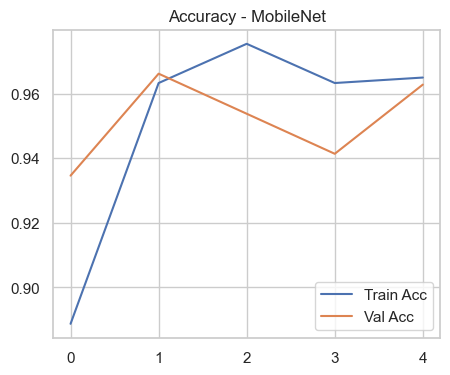

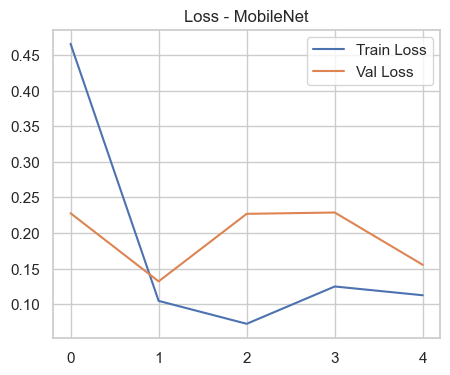

In [29]:
acc_m, prec_m, rec_m, f1_m = evaluate_model(
    mobilenet_model, val_loader, device, class_names, history_mobilenet, "MobileNet"
)

In [30]:
storeResults("MobileNet", acc_m, prec_m, rec_m, f1_m)

# EfficientNet-B0

In [31]:
efficientnet_model = timm.create_model(
    'efficientnet_b0',     
    pretrained=True,
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(efficientnet_model.parameters(), lr=0.001)


In [32]:
history_efficientnet = train_model(
    efficientnet_model, train_loader, val_loader,
    criterion, optimizer,
    epochs=5, device=device, model_name="EfficientNet-B0"
)


EfficientNet-B0 Epoch 1/5 | Train Loss: 0.5231 | Train Acc: 0.8862 | Val Loss: 0.2201 | Val Acc: 0.9369


EfficientNet-B0 Epoch 2/5 | Train Loss: 0.2328 | Train Acc: 0.9365 | Val Loss: 1.6266 | Val Acc: 0.9256


EfficientNet-B0 Epoch 3/5 | Train Loss: 0.5721 | Train Acc: 0.9147 | Val Loss: 0.1848 | Val Acc: 0.9369


EfficientNet-B0 Epoch 4/5 | Train Loss: 0.1524 | Train Acc: 0.9492 | Val Loss: 0.1260 | Val Acc: 0.9639


EfficientNet-B0 Epoch 5/5 | Train Loss: 0.0838 | Train Acc: 0.9749 | Val Loss: 0.1173 | Val Acc: 0.9651


In [33]:
torch.save(efficientnet_model.state_dict(), "Models/efficientnet_b0.pth")


Classification Report - EfficientNet-B0
              precision    recall  f1-score   support

     cyclone       0.99      0.97      0.98       186
  earthquake       0.98      0.95      0.96       270
       flood       0.93      0.97      0.95       215
    wildfire       0.97      0.98      0.98       216

    accuracy                           0.97       887
   macro avg       0.97      0.97      0.97       887
weighted avg       0.97      0.97      0.97       887



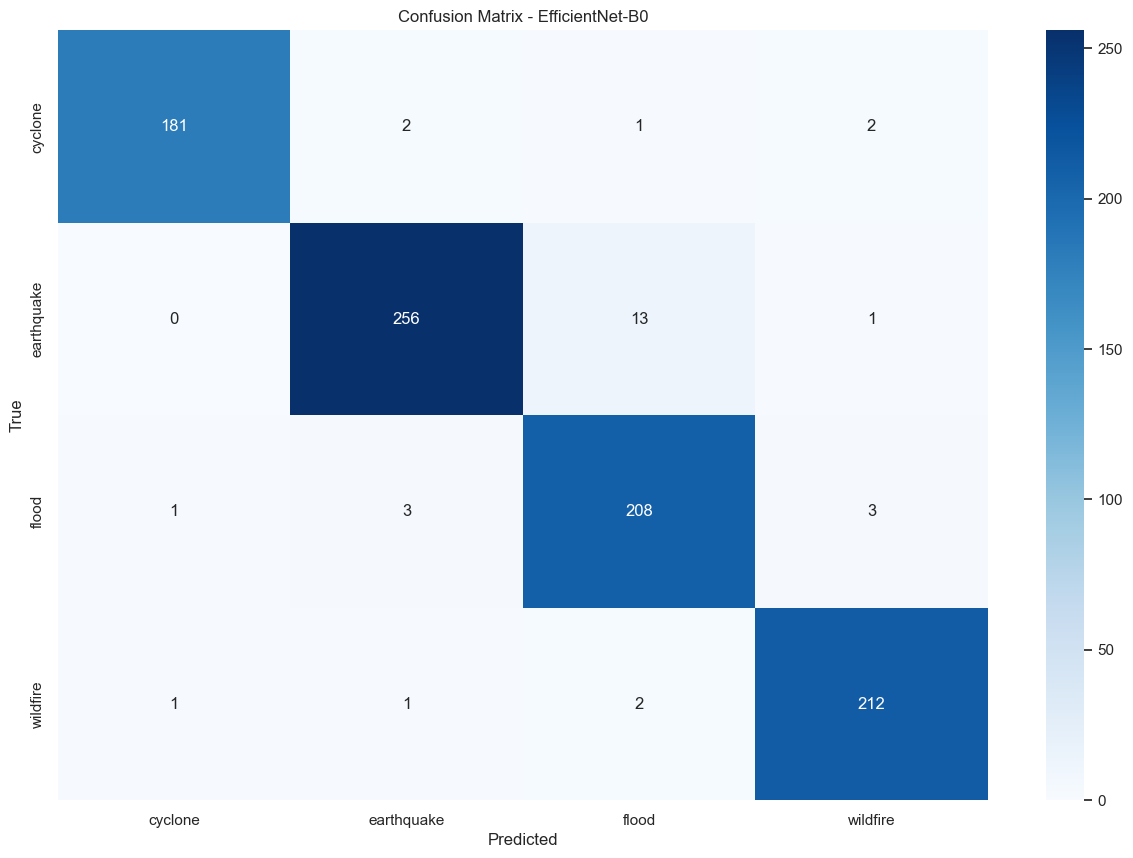

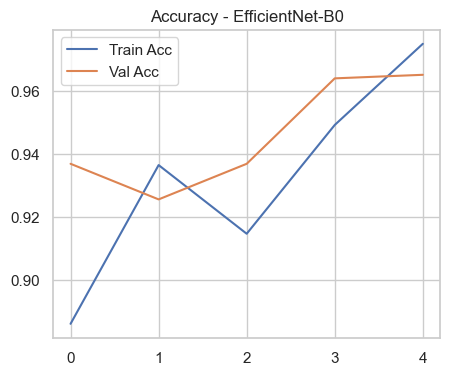

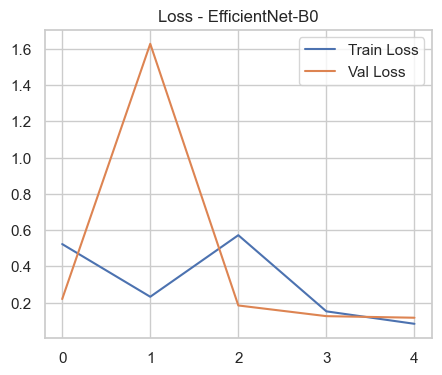

In [34]:
acc_e, prec_e, rec_e, f1_e = evaluate_model(
    efficientnet_model, val_loader, device, class_names, history_efficientnet, "EfficientNet-B0"
)

In [35]:
storeResults("EfficientNet-B0", acc_e, prec_e, rec_e, f1_e)

# Comparison

In [36]:
import pandas as pd

result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                        'Precision': precision,
                        'Recall'   : recall,
                        'F1 score' : f1score,
                      })

In [37]:
result

,ML Model,Accuracy,Precision,Recall,F1 score
0,ResNet50,0.961,0.961,0.961,0.961
1,VGG16,0.880,0.886,0.882,0.880
2,MobileNet,0.961,0.963,0.961,0.962
3,EfficientNet-B0,0.966,0.967,0.968,0.967


# Graph 

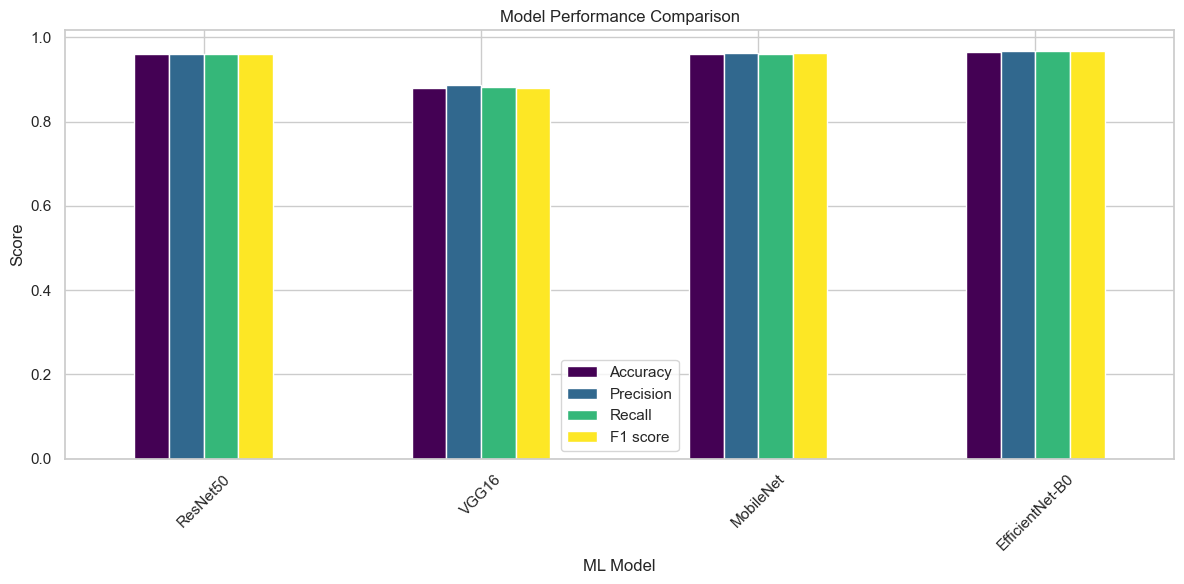

In [38]:
result.set_index('ML Model', inplace=True)
result.plot(kind="bar", figsize=(12, 6), colormap='viridis')
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

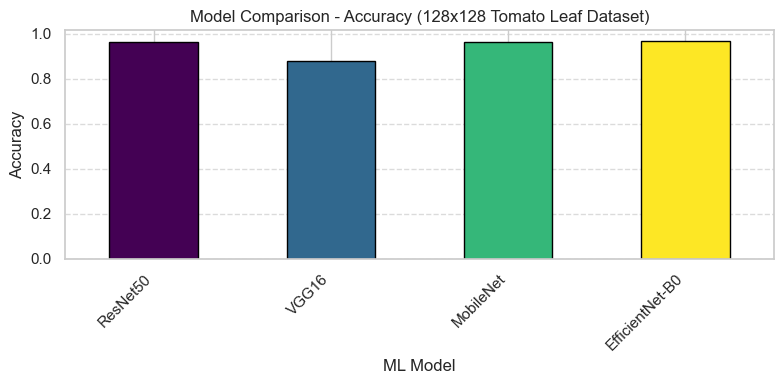

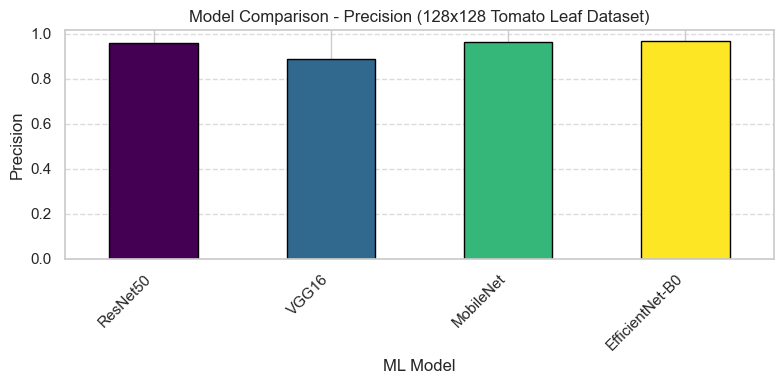

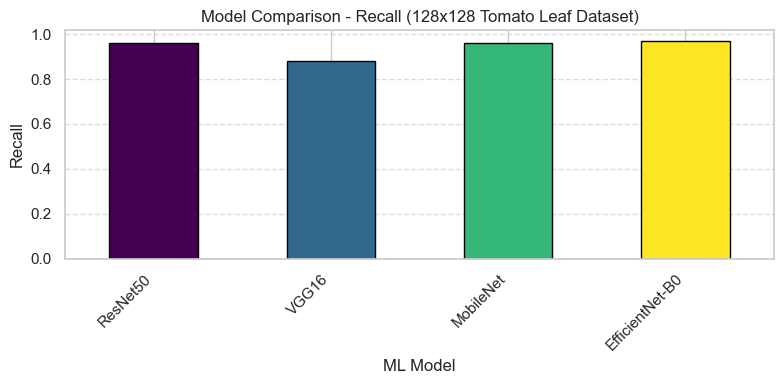

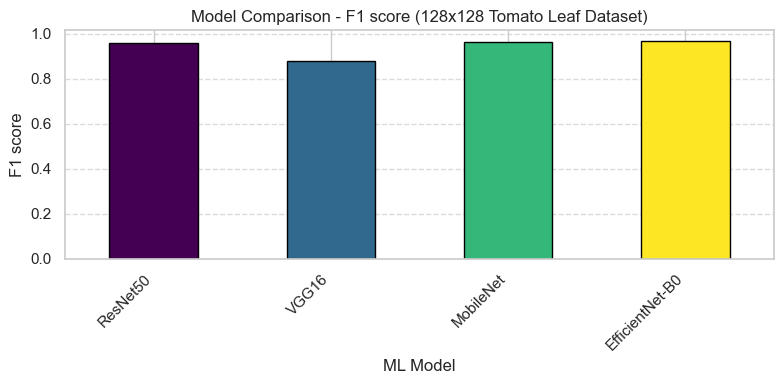

In [39]:
# Plot each metric separately
metrics = ["Accuracy", "Precision", "Recall", "F1 score"]

for metric in metrics:
    plt.figure(figsize=(8, 4))
    colors = plt.cm.viridis(np.linspace(0, 1, len(result)))  # pick colormap
    result[metric].plot(kind="bar", color=colors, edgecolor="black")
    plt.title(f"Model Comparison - {metric} (128x128 Tomato Leaf Dataset)")
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

In [40]:
num_class_names

16

# Prediction

In [1]:
import torch
import timm
import torch.nn as nn
from torchvision import transforms
from PIL import Image


device = torch.device("cpu")

num_classes = 4 
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=num_classes).to(device)
model.load_state_dict(torch.load("Models/efficientnet_b0.pth", map_location=device))
model.eval()

EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2

In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

In [3]:
import torch.nn.functional as F

def predict_image(model, image_path, class_names):
    image = Image.open(image_path).convert("RGB")
    img_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = F.softmax(outputs, dim=1)
        confidence, pred_class = torch.max(probs, dim=1)

    predicted_label = class_names[pred_class.item()]
    return predicted_label, confidence.item()


In [4]:
class_names = ['cyclone', 'earthquake', 'flood', 'wildfire']

image_path = "output/val/cyclone/test_795.jpg"
label, prob = predict_image(model, image_path, class_names)

print("Predicted Class :", label)
print("Confidence      :", round(prob, 3))

Predicted Class : cyclone
Confidence      : 1.0


In [5]:
image_path = "output/val/earthquake/test_1150.jpg"
label, prob = predict_image(model, image_path, class_names)

print("Predicted Class :", label)
print("Confidence      :", round(prob, 3))

Predicted Class : earthquake
Confidence      : 1.0


In [6]:
image_path = "output/val/flood/test_913.jpg"
label, prob = predict_image(model, image_path, class_names)

print("Predicted Class :", label)
print("Confidence      :", round(prob, 3))

Predicted Class : flood
Confidence      : 1.0


In [7]:
image_path = "output/val/wildfire/test_931.jpg"
label, prob = predict_image(model, image_path, class_names)

print("Predicted Class :", label)
print("Confidence      :", round(prob, 3))

Predicted Class : wildfire
Confidence      : 1.0


In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        # Hook gradients
        target_layer.register_backward_hook(self.save_gradients)
        target_layer.register_forward_hook(self.save_activations)

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def save_activations(self, module, input, output):
        self.activations = output

    def generate_cam(self, input_tensor, class_idx=None):
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = torch.argmax(output)

        # Backward
        self.model.zero_grad()
        class_score = output[0, class_idx]
        class_score.backward()

        gradients = self.gradients.mean(dim=[0, 2, 3])   # GAP over H,W
        activations = self.activations[0]

        weights = gradients

        # FIX: create CAM tensor on SAME DEVICE
        cam = torch.zeros(activations.shape[1:], dtype=torch.float32, device=activations.device)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)

        cam -= cam.min()
        cam /= cam.max()

        return cam.detach().cpu().numpy()


        return cam.detach().cpu().numpy()


In [9]:
target_layer = model.conv_head     
gradcam = GradCAM(model, target_layer)

In [10]:
def generate_gradcam(image_path, model, gradcam, transform):
    # Load and preprocess the image
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        pred_class = output.argmax(dim=1).item()

    # Generate CAM
    cam = gradcam.generate_cam(img_tensor, pred_class)

    # Convert CAM to heatmap
    cam = cv2.resize(cam, (img.size[0], img.size[1]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)

    # Superimpose
    img_np = np.array(img)
    superimposed_img = 0.4 * heatmap + 0.6 * img_np

    return img_np, heatmap, superimposed_img


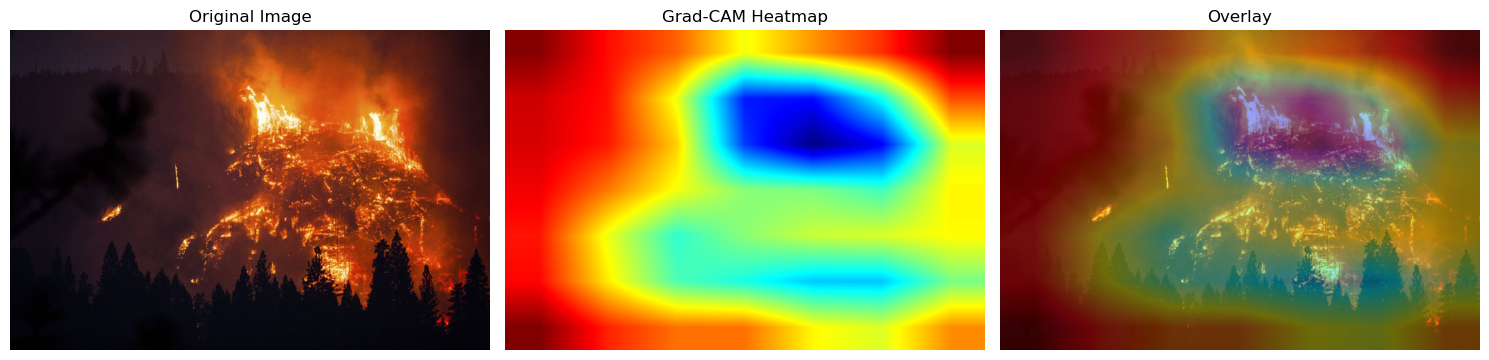

In [14]:
orig, heatmap, cam_img = generate_gradcam(
    image_path,
    model,
    gradcam,
    transform
)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(orig)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Grad-CAM Heatmap")
plt.imshow(heatmap)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(cam_img.astype("uint8"))
plt.axis("off")

plt.tight_layout()
plt.show()
